# Notebook 2: Context-Specific Fitness Gene Identification

This notebook identifies context-specific essential genes across all cancer
indications in the DepMap using a consensus of three complementary statistical tests.

**Approach:** For each cancer indication, we test every gene for differential
essentiality (stronger fitness dependency in that indication vs. all others) using:

1. **Fisher's exact test** — Tests enrichment of dependency (binarized at a score
   cutoff) in the indication. Robust for small sample sizes and does not assume
   normality.

2. **Independent two-sample t-test** — Tests difference in mean dependency scores.
   Assumes approximately normal distributions; powerful when this assumption holds.

3. **Wilcoxon rank-sum test** — Non-parametric test for differences in score distributions.
   Makes no distributional assumptions but requires adequate sample sizes for power.

**Rationale for three tests:** Each test captures a different aspect of the dependency
signal and makes different assumptions. Fisher's exact test detects enrichment of
strongly dependent cell lines; the t-test detects shifts in mean effect size;
and the Wilcoxon test detects distributional shifts without parametric assumptions.
By taking the **intersection** of hits from all three tests, we identify genes
supported by multiple lines of statistical evidence, reducing false positives that
may arise from violations of any single test's assumptions. For indications with
very few cell lines (N < 10), we exclude the Wilcoxon rank-sum test, which
lacks statistical power at small sample sizes.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn2
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../../data'
FIG_DIR = '../../figures/depmap_analysis'
os.makedirs(FIG_DIR, exist_ok=True)

# ── Plot style ────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
})

In [ ]:
# ── Load preprocessed data from Notebook 1 ────────────────
gene_effect = pd.read_csv(
    os.path.join(DATA_DIR, 'gene_effect_annotated.csv'),
    index_col=0
)

indications = gene_effect['indication']
scores = gene_effect.drop(columns=['indication'])

print(f'Loaded: {scores.shape[0]} cell lines x {scores.shape[1]} genes')
print(f'Indications: {indications.nunique()}')

Loaded: 1208 cell lines x 18531 genes
Indications: 167


## 2.1 Define the Statistical Testing Framework

We implement three statistical tests for each gene x indication pair.
The fitness effect score cutoff for Fisher's exact test binarization is set at
**−0.6**, which is slightly more stringent than the commonly used −0.5 threshold
and helps reduce false positives from weakly dependent cell lines.

In [ ]:
# ── Parameters ────────────────────────────────────────────
DEPENDENCY_CUTOFF = -0.6    # Score threshold for Fisher's exact test binarization
P_VALUE_CUTOFF = 0.05       # Significance threshold per-test
TOP_N_GENES = 10            # Number of top genes to retain per test
MIN_CELLS_WILCOXON = 10     # Minimum indication size for Wilcoxon test

print(f'Parameters:')
print(f'  Dependency cutoff (Fisher):  {DEPENDENCY_CUTOFF}')
print(f'  P-value cutoff:              {P_VALUE_CUTOFF}')
print(f'  Top N genes per test:        {TOP_N_GENES}')
print(f'  Min cells for Wilcoxon:      {MIN_CELLS_WILCOXON}')

Parameters:
  Dependency cutoff (Fisher):  -0.6
  P-value cutoff:              0.05
  Top N genes per test:        10
  Min cells for Wilcoxon:      10


In [ ]:
def run_context_specific_tests(scores_df, indications_series, indication,
                                dep_cutoff=DEPENDENCY_CUTOFF,
                                p_cutoff=P_VALUE_CUTOFF,
                                top_n=TOP_N_GENES,
                                min_wilcoxon=MIN_CELLS_WILCOXON):
    """
    Identify context-specific fitness genes for a given cancer indication.

    For each gene, compares dependency scores in the target indication
    against all other cell lines using three statistical tests.

    Parameters
    ----------
    scores_df : pd.DataFrame
        Gene-effect scores (cell lines × genes). More negative = more essential.
    indications_series : pd.Series
        Cancer type label for each cell line (same index as scores_df).
    indication : str
        Target cancer indication to test.
    dep_cutoff : float
        Score threshold for binarizing dependency (Fisher's exact test).
    p_cutoff : float
        P-value significance threshold.
    top_n : int
        Number of top-ranked genes to retain from each test.
    min_wilcoxon : int
        Minimum number of indication cell lines required for Wilcoxon test.

    Returns
    -------
    results : dict with keys 'fisher', 'ttest', 'wilcoxon', 'consensus',
              'all_results', 'n_indication', 'n_other'.
    """
    # Partition cell lines
    mask_in = indications_series == indication
    mask_out = ~mask_in
    n_in = mask_in.sum()
    n_out = mask_out.sum()

    scores_in = scores_df[mask_in]
    scores_out = scores_df[mask_out]

    genes = scores_df.columns.tolist()

    # Storage for all per-gene results
    all_results = []

    for gene in genes:
        vals_in = scores_in[gene].dropna()
        vals_out = scores_out[gene].dropna()

        if len(vals_in) < 2 or len(vals_out) < 2:
            continue

        row = {'gene': gene, 'mean_in': vals_in.mean(), 'mean_out': vals_out.mean(),
               'mean_diff': vals_in.mean() - vals_out.mean()}

        # ── Test 1: Fisher's exact test ──────────────────────
        # Binarize: is the cell line dependent (score < cutoff)?
        dep_in = (vals_in < dep_cutoff).sum()
        nodep_in = len(vals_in) - dep_in
        dep_out = (vals_out < dep_cutoff).sum()
        nodep_out = len(vals_out) - dep_out

        contingency = [[dep_in, nodep_in], [dep_out, nodep_out]]
        _, p_fisher = stats.fisher_exact(contingency, alternative='greater')
        row['p_fisher'] = p_fisher
        row['dep_frac_in'] = dep_in / len(vals_in)
        row['dep_frac_out'] = dep_out / len(vals_out)

        # ── Test 2: Independent t-test ───────────────────────
        # One-sided: indication scores are MORE NEGATIVE (more essential)
        t_stat, p_ttest = stats.ttest_ind(vals_in, vals_out, alternative='less') #equal_var=False,
        # p_ttest = p_ttest_two / 2 if t_stat < 0 else 1 - p_ttest_two / 2
        row['t_stat'] = t_stat
        row['p_ttest'] = p_ttest

        # ── Test 3: Wilcoxon rank-sum test ───────────────────
        # One-sided: indication scores are stochastically smaller (more essential)
        u_stat, p_wilcox_two = stats.mannwhitneyu(vals_in, vals_out, alternative='less')
        row['p_wilcoxon'] = p_wilcox_two

        all_results.append(row)

    df = pd.DataFrame(all_results)

    # ── Multiple testing correction (Benjamini-Hochberg FDR) ──
    for test_col in ['p_fisher', 'p_ttest', 'p_wilcoxon']:
        valid = df[test_col].notna()
        if valid.sum() > 0:
            _, fdr_vals, _, _ = multipletests(df.loc[valid, test_col],
                                              alpha=0.05, method='fdr_bh')
            df.loc[valid, test_col] = fdr_vals
            # df.insert(loc=len(df.columns), column=f'{test_col}_fdr', value=fdr_vals)

    # ── Select top hits per test ──────────────────────────────
    fisher_hits = set(
        df[df['p_fisher'] < p_cutoff]
        .nsmallest(top_n, 'p_fisher')['gene']
    )

    ttest_hits = set(
        df[df['p_ttest'] < p_cutoff]
        .nsmallest(top_n, 'p_ttest')['gene']
    )

    wilcoxon_hits = set(
            df[df['p_wilcoxon'] < p_cutoff]
            .nsmallest(top_n, 'p_wilcoxon')['gene']
        )

    if n_in >= min_wilcoxon:
        consensus = fisher_hits & ttest_hits & wilcoxon_hits
    else:
        consensus = fisher_hits & ttest_hits  # 2-test consensus for small N

    return {
        'fisher': fisher_hits,
        'ttest': ttest_hits,
        'wilcoxon': wilcoxon_hits,
        'consensus': consensus,
        'all_results': df,
        'n_indication': n_in,
        'n_other': n_out,
        'use_wilcoxon': n_in >= min_wilcoxon,
    }

## 2.2 Run Analysis Across All Indications

We apply the three-test framework to every cancer indication that has
at least 4 cell lines in the DepMap. This produces a pan-indication
catalog of context-specific fitness genes.

In [ ]:
# ── Run pan-indication analysis ───────────────────────────
MIN_INDICATION_SIZE = 4  # require at least 4 cell lines

indication_counts = indications.value_counts()
indications_to_test = indication_counts[
    indication_counts >= MIN_INDICATION_SIZE
].index.tolist()

print(f'Testing {len(indications_to_test)} indications '
      f'(≥{MIN_INDICATION_SIZE} cell lines each)\n')

all_indication_results = {}

for i, indication in enumerate(indications_to_test):
    n = indication_counts[indication]
    result = run_context_specific_tests(scores, indications, indication)
    all_indication_results[indication] = result

    n_consensus = len(result['consensus'])
    wilcox_note = '' if result['use_wilcoxon'] else ' (2-test, N<10)'

    if n_consensus > 0:
        genes_str = ', '.join(sorted(result['consensus']))
        print(f'  [{i+1}/{len(indications_to_test)}] {indication} '
              f'(N={n}): {n_consensus} consensus gene(s){wilcox_note}: {genes_str}')

    if (i+1) % 10 == 0:
        total_found = sum(len(r['consensus']) for r in all_indication_results.values())
        print(f'  ... processed {i+1}/{len(indications_to_test)}, '
              f'{total_found} consensus genes found so far')

# Summary
total_consensus = sum(len(r['consensus']) for r in all_indication_results.values())
indications_with_hits = sum(1 for r in all_indication_results.values() if len(r['consensus']) > 0)
print(f'\n══════════════════════════════════════════════════════')
print(f'Analysis complete.')
print(f'  {total_consensus} total consensus context-specific genes found')
print(f'  across {indications_with_hits} / {len(indications_to_test)} indications')

# Save the results
with open(os.path.join(DATA_DIR, "all_indication_results.pkl"), "wb") as f:
    pickle.dump(all_indication_results, f)

Testing 71 indications (≥4 cell lines each)

  [1/71] Melanoma (N=55): 7 consensus gene(s): BRAF, DUSP4, MAPK1, PEA15, PPP2R2A, SOX10, ZEB2
  [2/71] Oral Cavity Squamous Cell Carcinoma (N=53): 5 consensus gene(s): EDF1, EGFR, ITGB1, SNAI2, TP63
  [3/71] Lung Adenocarcinoma (N=53): 1 consensus gene(s): UXS1
  [4/71] Glioblastoma, IDH-Wildtype (N=50): 6 consensus gene(s): CTDNEP1, FERMT2, JUN, LMNA, PRKAR1A, RPP25L
  [5/71] Colon Adenocarcinoma (N=48): 3 consensus gene(s): CTNNB1, KLF5, TCF7L2
  [6/71] Pancreatic Adenocarcinoma (N=46): 4 consensus gene(s): DOCK5, ID1, KRAS, RAB10
  [7/71] Neuroblastoma (N=41): 4 consensus gene(s): GATA3, HAND2, ISL1, LDB1
  [8/71] Bladder Urothelial Carcinoma (N=30): 1 consensus gene(s): SOX4
  [9/71] Ewing Sarcoma (N=28): 4 consensus gene(s): ETV6, FLI1, STAG1, TRIM8
  [10/71] Osteosarcoma (N=25): 1 consensus gene(s): SUB1
  ... processed 10/71, 36 consensus genes found so far
  [11/71] Small Cell Lung Cancer (N=25): 3 consensus gene(s): CCNE2, E2F3, SO

## 2.3 Examine AT/RT Results and ZMYM3 Discovery

In [ ]:
# Open the saved results, so the lengthy analysis does not have to be re-run
with open(os.path.join(DATA_DIR, "all_indication_results.pkl"), 'rb') as file:
    all_indication_results = pickle.load(file)

In [ ]:
# ── Identify the AT/RT indication key ────────────────────
atrt_keys = [k for k in all_indication_results.keys()
             if any(kw in k.lower() for kw in ['rhabdoid', 'atrt', 'teratoid'])]

if not atrt_keys:
    # If not found, list all indications for manual inspection
    print('AT/RT indication not found automatically. Available indications:')
    for k in sorted(all_indication_results.keys()):
        print(f'  {k}')
    print('\nSet ATRT_KEY manually below.')
    ATRT_KEY = None
else:
    ATRT_KEY = atrt_keys[0]
    print(f'AT/RT indication found: "{ATRT_KEY}"')
    if len(atrt_keys) > 1:
        print(f'  (Multiple matches: {atrt_keys}; using first)')

AT/RT indication found: "Atypical Teratoid/Rhabdoid Tumor"


In [ ]:
# ── Display AT/RT consensus results ──────────────────────
if ATRT_KEY and ATRT_KEY in all_indication_results:
    atrt_res = all_indication_results[ATRT_KEY]

    print(f'AT/RT Context-Specific Analysis')
    print(f'═══════════════════════════════════════════')
    print(f'Cell lines in indication: {atrt_res["n_indication"]}')
    print(f'Cell lines in background: {atrt_res["n_other"]}')
    print(f'Wilcoxon test used: {atrt_res["use_wilcoxon"]}')
    print(f'\nFisher\'s exact hits:   {len(atrt_res["fisher"])}: {sorted(atrt_res["fisher"])}')
    print(f'T-test hits:            {len(atrt_res["ttest"])}: {sorted(atrt_res["ttest"])}')
    print(f'Wilcoxon hits:          {len(atrt_res["wilcoxon"])}: {sorted(atrt_res["wilcoxon"])}')
    print(f'\n★ CONSENSUS GENES:      {sorted(atrt_res["consensus"])}')

    # Detailed stats for consensus genes
    if atrt_res['consensus']:
        print(f'\nDetailed statistics for consensus genes:')
        df_all = atrt_res['all_results']
        consensus_df = df_all[df_all['gene'].isin(atrt_res['consensus'])].copy()
        consensus_df = consensus_df.sort_values('p_fisher')
        print(consensus_df[['gene', 'mean_in', 'mean_out', 'mean_diff',
                            'dep_frac_in', 'dep_frac_out',
                            'p_fisher', 'p_ttest', 'p_wilcoxon']].to_string(index=False))
else:
    print('AT/RT not found in results. Set ATRT_KEY manually and re-run.')

AT/RT Context-Specific Analysis
═══════════════════════════════════════════
Cell lines in indication: 16
Cell lines in background: 1192
Wilcoxon test used: True

Fisher's exact hits:   10: ['BRAP', 'FAM83E', 'MIB1', 'NABP2', 'NXT1', 'PHIP', 'PPM1D', 'PPM1G', 'SMARCD1', 'ZMYM3']
T-test hits:            10: ['DCAF5', 'DDX31', 'EZH2', 'FAM83E', 'H2AZ2', 'NABP2', 'PPM1G', 'QRICH1', 'SMARCD1', 'ZMYM3']
Wilcoxon hits:          10: ['DCAF5', 'DCUN1D2', 'EED', 'EZH2', 'H2AZ2', 'NABP2', 'POLR1E', 'QRICH1', 'SMARCD1', 'ZMYM3']

★ CONSENSUS GENES:      ['NABP2', 'SMARCD1', 'ZMYM3']

Detailed statistics for consensus genes:
   gene   mean_in  mean_out  mean_diff  dep_frac_in  dep_frac_out     p_fisher      p_ttest  p_wilcoxon
SMARCD1 -0.816512 -0.207960  -0.608551       0.8750      0.093960 1.692250e-08 1.962180e-12    0.000037
  NABP2 -0.634910 -0.150679  -0.484232       0.5000      0.016779 2.255467e-06 7.303024e-22    0.000145
  ZMYM3 -0.626475 -0.139272  -0.487203       0.5625      0.028523 2.

## 2.4 Report Figures

### Figure 1: Venn Diagram of Statistical Test Overlap

Shows the intersection of hits from the three statistical tests for AT/RT,
demonstrating the consensus approach.

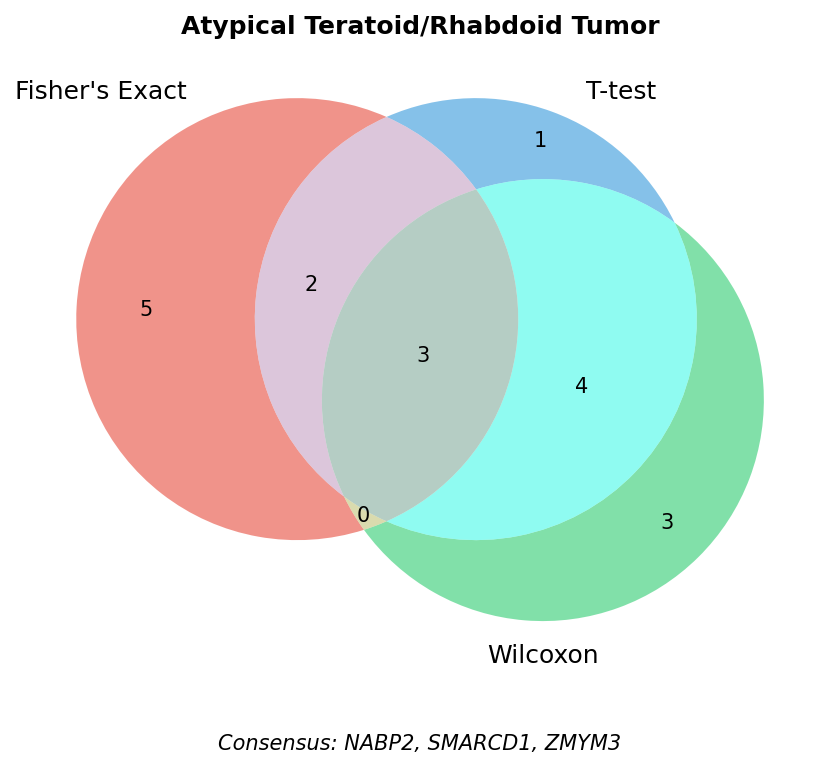

Saved: fig1_venn_atrt.pdf/png


In [ ]:
# ── Figure 1: Venn diagram (AT/RT) ─────────────────────────
def plot_venn_indication(result, indication_name, ax=None):
    """Plot Venn diagram of test overlaps for one indication."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    f = result['fisher']
    t = result['ttest']
    w = result['wilcoxon']

    if result['use_wilcoxon'] and len(w) > 0:
        v = venn3([f, t, w],
                  set_labels=("Fisher's Exact", 'T-test', 'Wilcoxon'),
                  set_colors=('#e74c3c', '#3498db', '#2ecc71'),
                  alpha=0.6, ax=ax)
    else:
        v = venn2([f, t],
                  set_labels=("Fisher's Exact", 'T-test'),
                  set_colors=('#e74c3c', '#3498db'),
                  alpha=0.6, ax=ax)

    ax.set_title(indication_name, fontsize=12, fontweight='bold')
    return ax

# Try to import matplotlib_venn; if not available, skip
try:
    from matplotlib_venn import venn3, venn2

    if ATRT_KEY:
        fig, ax = plt.subplots(figsize=(6, 5))
        atrt_res = all_indication_results[ATRT_KEY]
        plot_venn_indication(atrt_res, ATRT_KEY, ax)
        if atrt_res['consensus']:
                genes_str = ', '.join(sorted(atrt_res['consensus']))
                ax.text(0.5, -0.12, f'Consensus: {genes_str}',
                            transform=ax.transAxes, ha='center',
                            fontsize=10, style='italic')

        fig.tight_layout()
        fig.savefig(os.path.join(FIG_DIR, 'fig1_venn_atrt.pdf'), bbox_inches='tight')
        fig.savefig(os.path.join(FIG_DIR, 'fig1_venn_atrt.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print('Saved: fig1_venn_atrt.pdf/png')
except ImportError:
    print('matplotlib_venn not installed. Install with: pip install matplotlib-venn')
    print('Skipping Venn diagram.')

### Figure S1: Multi-indication Venn Diagrams

Show Venn diagrams for multiple indications of interest, including
positive controls (e.g., Melanoma with BRAF, PDAC with KRAS).

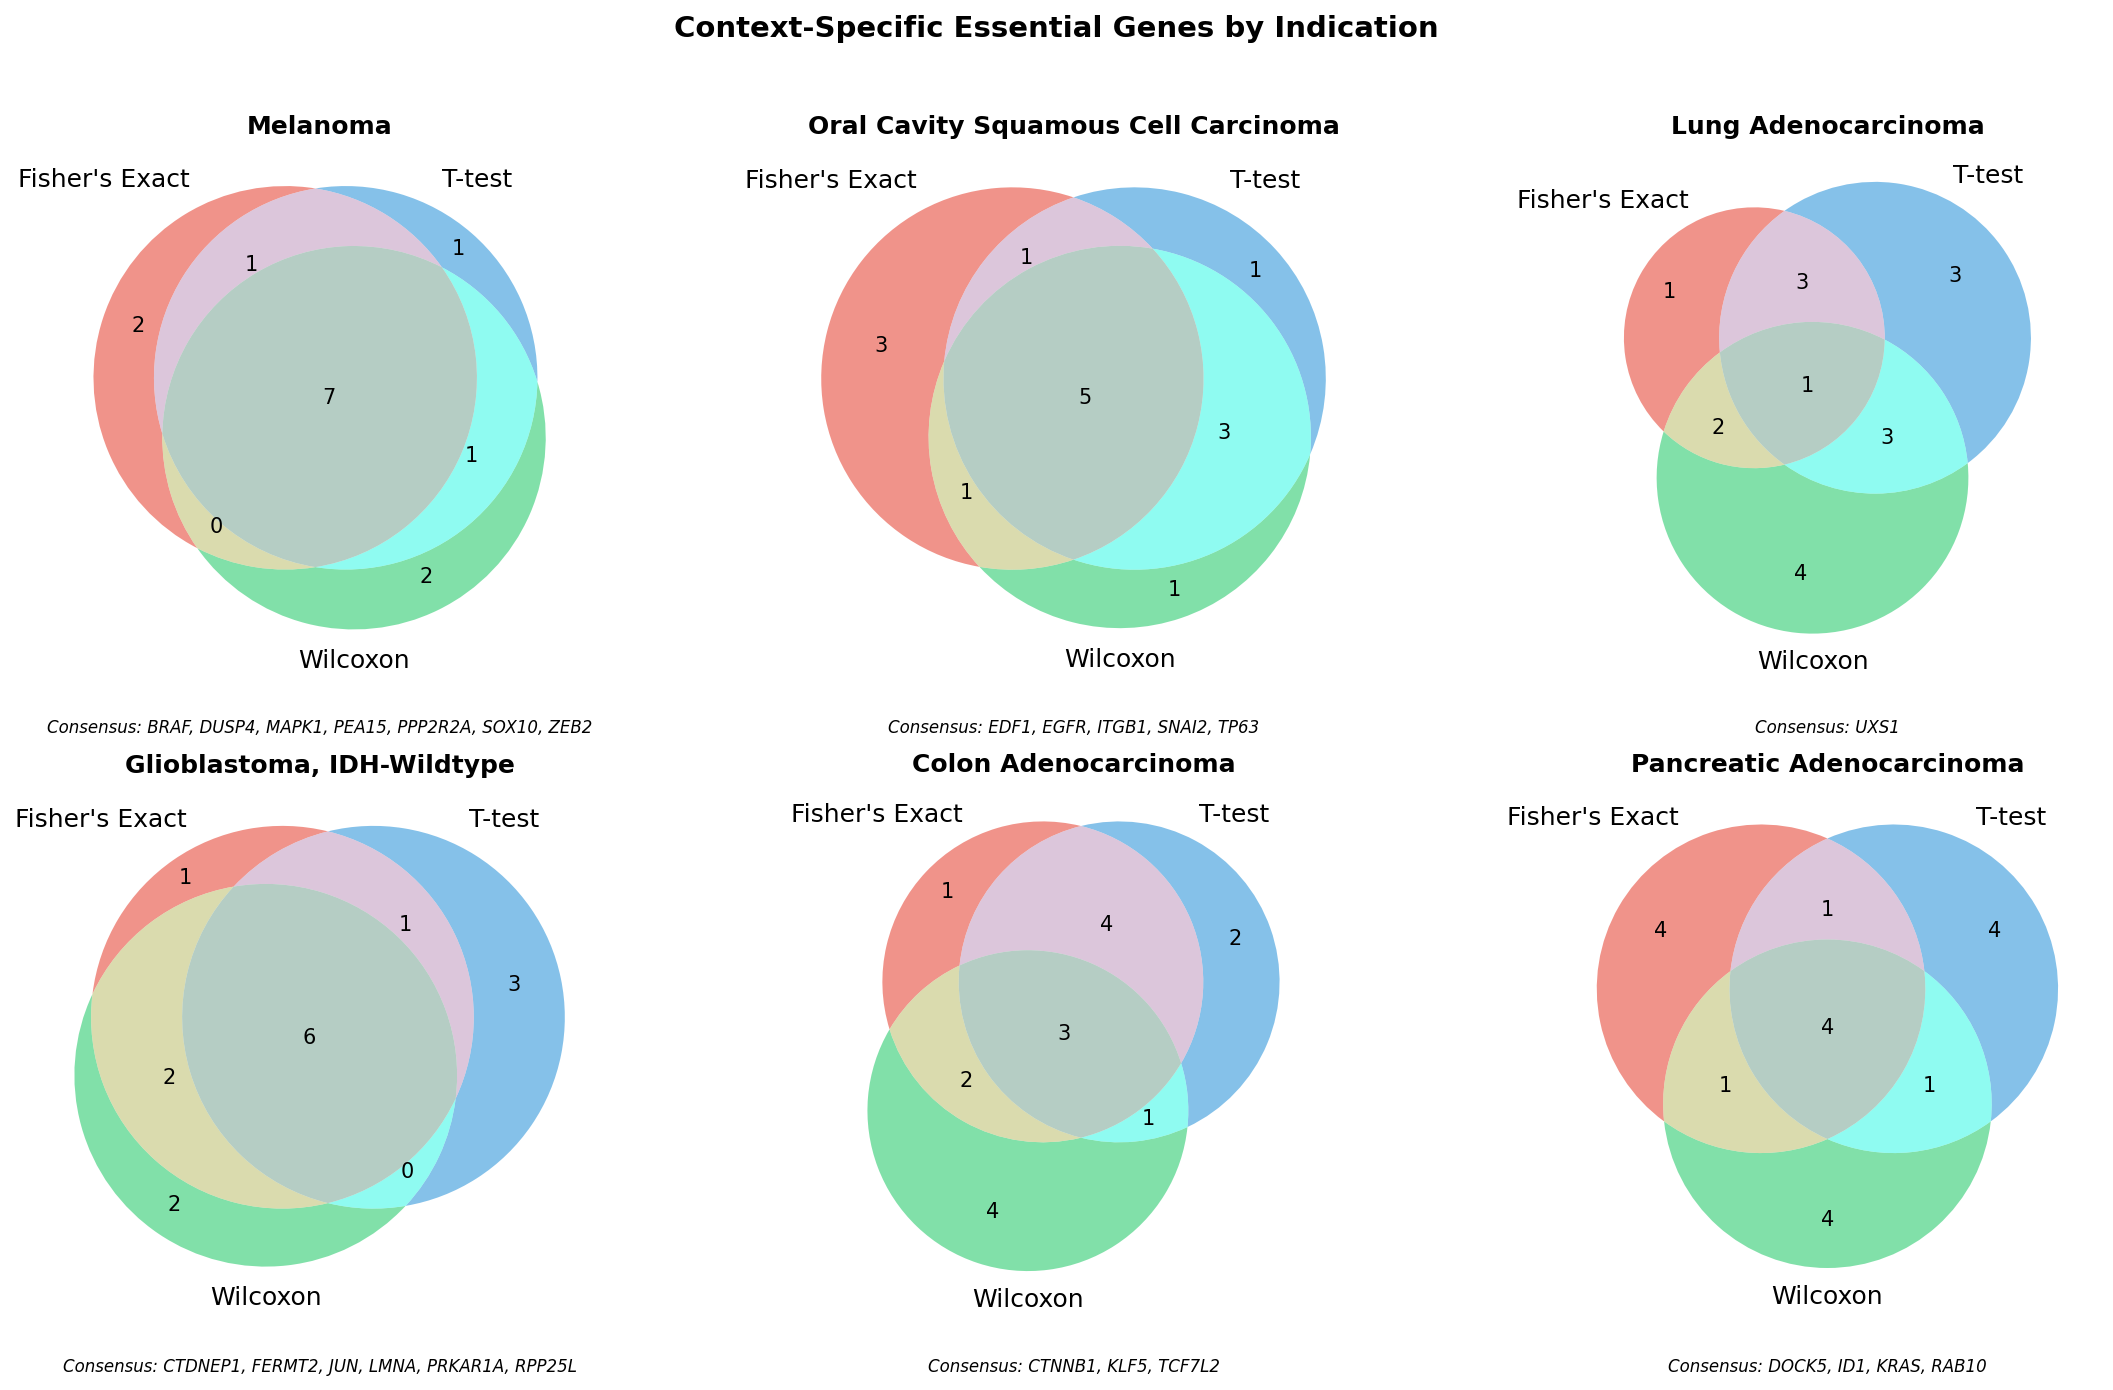

Saved: figS1_venn_multi.pdf/png


In [ ]:
# ── Multi-panel Venn diagrams ────────────────────────────
# Select indications with consensus hits for display
indications_with_consensus = [
    k for k, v in all_indication_results.items()
    if len(v['consensus']) > 0
]

# Define which indications to show
display_indications = []
for ind in indications_with_consensus:
    if ind not in display_indications and len(display_indications) < 6:
        display_indications.append(ind)

if display_indications:
    n_panels = len(display_indications)
    ncols = min(3, n_panels)
    nrows = (n_panels + ncols - 1) // ncols

    try:
        from matplotlib_venn import venn3, venn2
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows))
        if n_panels == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for i, ind in enumerate(display_indications):
            res = all_indication_results[ind]
            plot_venn_indication(res, ind, axes[i])
            # Add consensus gene names below
            if res['consensus']:
                genes_str = ', '.join(sorted(res['consensus']))
                axes[i].text(0.5, -0.12, f'Consensus: {genes_str}',
                            transform=axes[i].transAxes, ha='center',
                            fontsize=8, style='italic')

        # Hide unused axes
        for j in range(n_panels, len(axes)):
            axes[j].set_visible(False)

        fig.suptitle('Context-Specific Essential Genes by Indication',
                     fontsize=14, fontweight='bold', y=1.02)
        fig.tight_layout()
        fig.savefig(os.path.join(FIG_DIR, 'figS1_venn_multi.pdf'), bbox_inches='tight')
        fig.savefig(os.path.join(FIG_DIR, 'figS1_venn_multi.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print('Saved: figS1_venn_multi.pdf/png')
    except ImportError:
        print('matplotlib_venn not installed. Skipping.')

### Figure 2: ZMYM3 Dependency Across All Indications

Strip plot showing ZMYM3 gene-effect scores for every cell line,
grouped by cancer indication. AT/RT is highlighted.

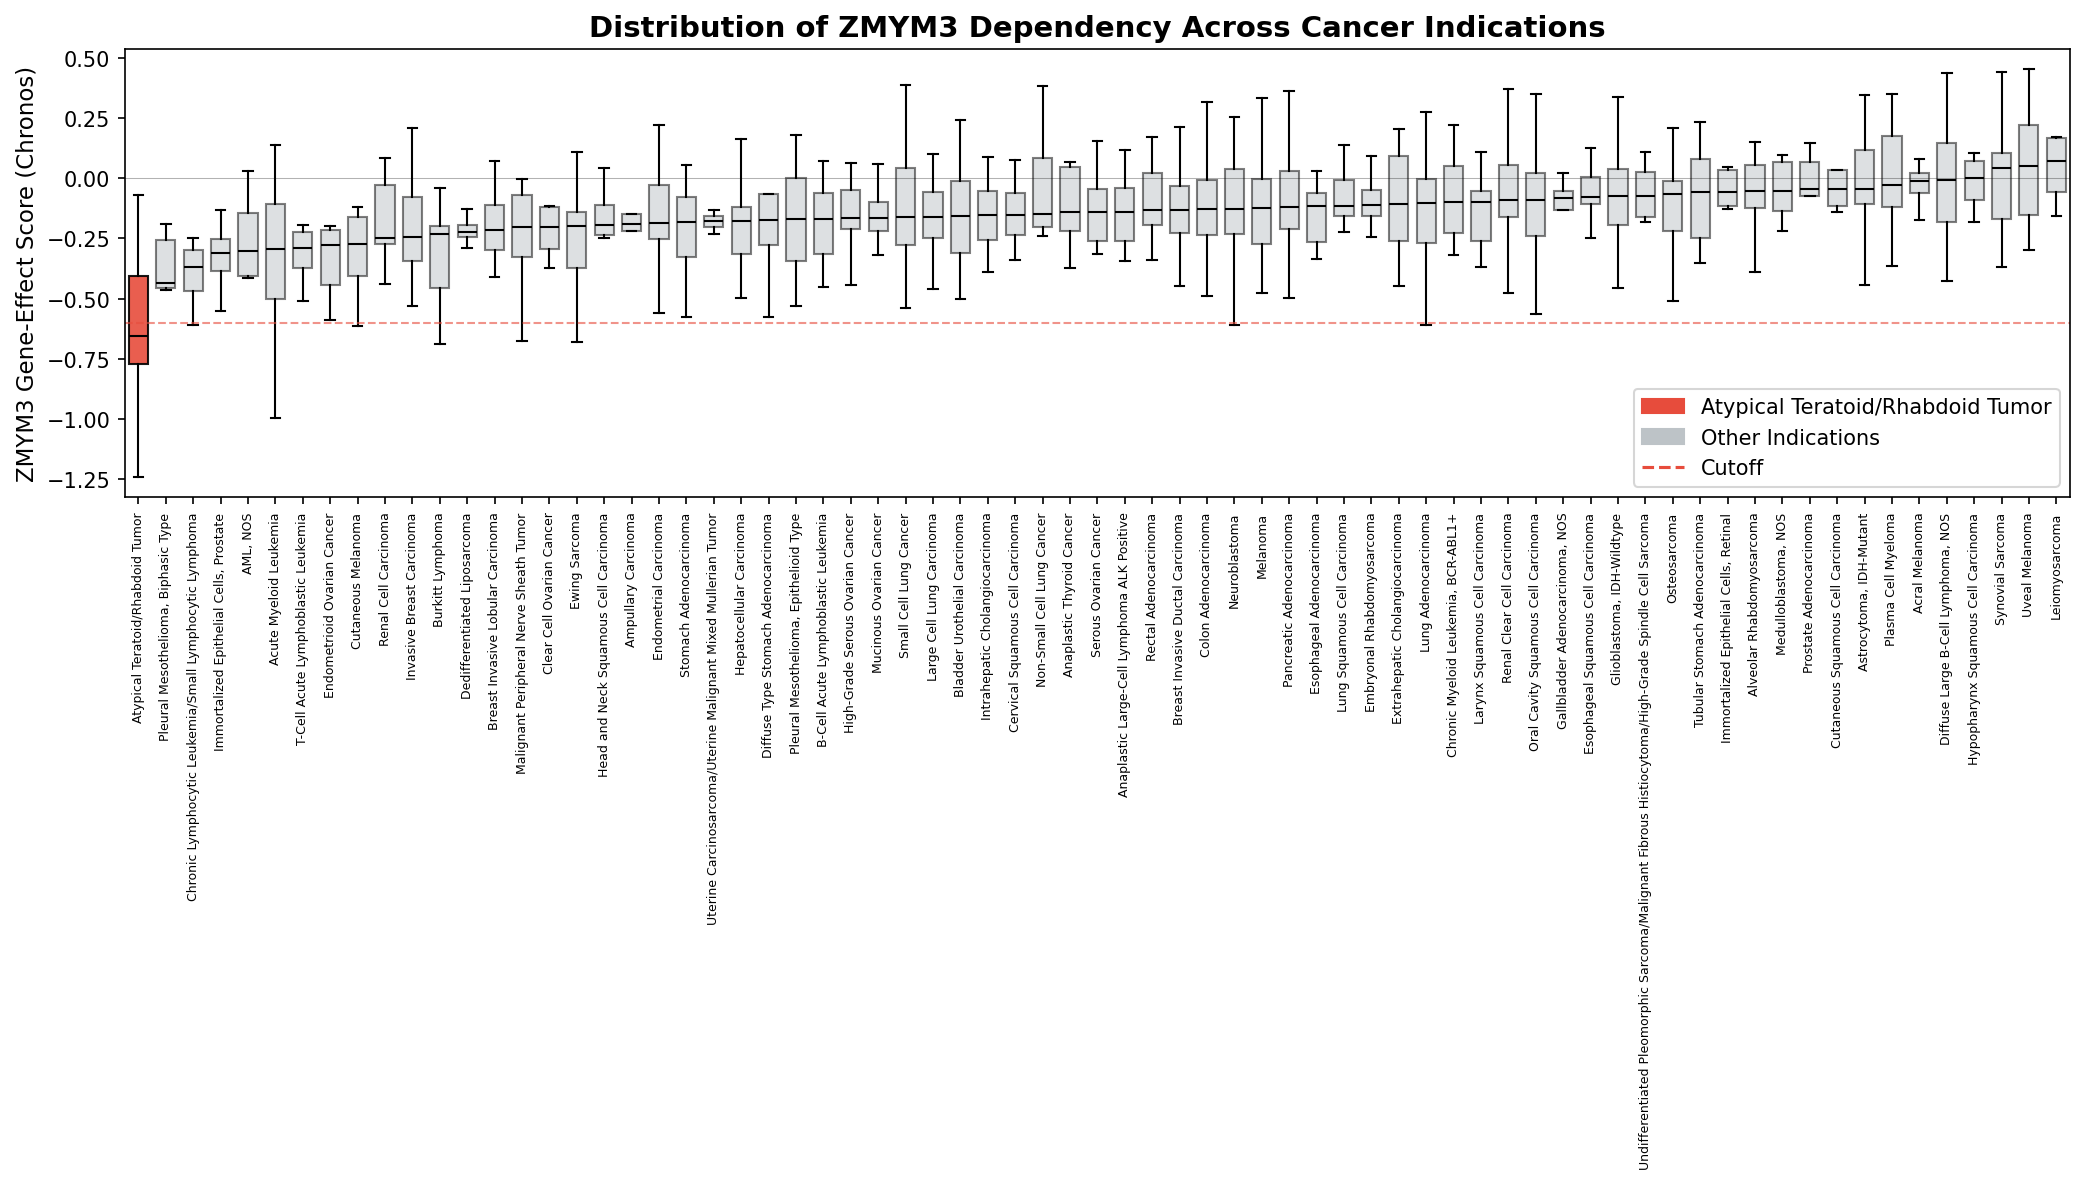

Saved: fig2a_ZMYM3_dep.pdf/png


In [ ]:
TARGET_GENE = 'ZMYM3'

if TARGET_GENE not in scores.columns:
    print(f'{TARGET_GENE} not found in gene-effect matrix.')
else:
    # Build plot dataframe
    plot_df = pd.DataFrame({
        'indication': indications,
        'score': scores[TARGET_GENE]
    }).dropna()

    indication_counts = indications.value_counts()
    indications_to_test = indication_counts[
        indication_counts >= 4
    ].index.tolist()

    plot_df = plot_df[plot_df['indication'].isin(indications_to_test)]

    # Order indications by median score (most essential first)
    ind_order = (
        plot_df.groupby('indication')['score']
        .median()
        .sort_values()
        .index.tolist()
    )

    fig, ax = plt.subplots(figsize=(14, 8))

    # Prepare data for boxplot
    data_to_plot = [plot_df[plot_df['indication'] == ind]['score'] for ind in ind_order]

    # Create boxplot (removing outliers for clarity in a dense plot)
    bp = ax.boxplot(data_to_plot, patch_artist=True, widths=0.7,
                    showfliers=False, medianprops={'color': 'black', 'linewidth': 1})

    # Color the boxes
    for i, ind in enumerate(ind_order):
        if ATRT_KEY and ATRT_KEY in ind:
            color = '#e74c3c'  # Highlight AT/RT in red
            alpha = 0.9
        else:
            color = '#bdc3c7'  # Others in light gray
            alpha = 0.5

        bp['boxes'][i].set_facecolor(color)
        bp['boxes'][i].set_alpha(alpha)

    # Add reference lines
    ax.axhline(y=DEPENDENCY_CUTOFF, color='#e74c3c', linestyle='--',
               linewidth=1, alpha=0.6, label=f'Essentiality Cutoff ({DEPENDENCY_CUTOFF})')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)

    # Formatting
    ax.set_xticks(range(1, len(ind_order) + 1))
    ax.set_xticklabels(ind_order, rotation=90, fontsize=6)
    ax.set_ylabel(f'{TARGET_GENE} Gene-Effect Score (Chronos)', fontsize=11)
    ax.set_title(f'Distribution of {TARGET_GENE} Dependency Across Cancer Indications',
                 fontsize=14, fontweight='bold')

    # Legend
    red_patch = mpatches.Patch(color='#e74c3c', label=f'{ATRT_KEY}')
    gray_patch = mpatches.Patch(color='#bdc3c7', label='Other Indications')
    ax.legend(handles=[red_patch, gray_patch,
                      plt.Line2D([0], [0], color='#e74c3c', linestyle='--', label='Cutoff')],
              fontsize=10, loc='lower right')

    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, 'fig2a_ZMYM3_dep.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(FIG_DIR, 'fig2a_ZMYM3_dep.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: fig2a_ZMYM3_dep.pdf/png')

## 2.5 Formal Specificity Test for ZMYM3 Dependency

The dependency-distribution figures above are descriptive: they show that AT/RT has the most negative median ZMYM3 score. To formally test specificity rather than relying on rank alone, we now perform pairwise one-sided Wilcoxon rank-sum tests comparing AT/RT ZMYM3 scores against each other indication individually, then correct for multiple testing with Benjamini–Hochberg FDR.

**Outputs:** the count and percentage of indications where AT/RT is significantly more dependent on ZMYM3, plus a z-score quantifying how far AT/RT's per-indication mean falls below the distribution of all other per-indication means.

In [ ]:
# ── Pairwise specificity test: AT/RT vs. each other indication ──
TARGET_GENE = 'ZMYM3'
FDR_THRESHOLD = 0.05
MIN_LINES_FOR_COMPARISON = 4  # match the threshold used elsewhere in this notebook

# Extract ZMYM3 scores and aligned indication labels
zmym3 = scores[TARGET_GENE].dropna()
ind_per_cell = indications.loc[zmym3.index]

# Restrict comparison set to indications with enough cell lines
ind_sizes = ind_per_cell.value_counts()
eligible = ind_sizes[ind_sizes >= MIN_LINES_FOR_COMPARISON].index

atrt_scores = zmym3[ind_per_cell == ATRT_KEY]
other_inds = [ind for ind in eligible if ind != ATRT_KEY]

print(f'AT/RT cell lines: {len(atrt_scores)}')
print(f'Comparison indications (>={MIN_LINES_FOR_COMPARISON} cell lines): {len(other_inds)}')
print()

# One-sided Wilcoxon rank-sum: AT/RT scores stochastically smaller (more essential)
rows = []
for ind in other_inds:
    other_scores = zmym3[ind_per_cell == ind]
    _, p = stats.mannwhitneyu(atrt_scores, other_scores, alternative='less')
    rows.append({
        'indication': ind,
        'n_lines': len(other_scores),
        'mean_score': other_scores.mean(),
        'p_value': p,
    })

spec_df = pd.DataFrame(rows)

# Benjamini–Hochberg FDR correction across all pairwise comparisons
_, fdr_vals, _, _ = multipletests(spec_df['p_value'], method='fdr_bh')
spec_df['fdr'] = fdr_vals
spec_df = spec_df.sort_values('fdr').reset_index(drop=True)

n_total = len(spec_df)
n_sig = int((spec_df['fdr'] < FDR_THRESHOLD).sum())
pct_sig = 100 * n_sig / n_total

print(f'Indications where AT/RT is significantly more dependent on {TARGET_GENE} '
      f'(FDR < {FDR_THRESHOLD}):')
print(f'  {n_sig} of {n_total} indications ({pct_sig:.1f}%)')

AT/RT cell lines: 16
Comparison indications (>=4 cell lines): 70

Indications where AT/RT is significantly more dependent on ZMYM3 (FDR < 0.05):
  68 of 70 indications (97.1%)


In [ ]:
# ── Z-score of AT/RT mean vs. distribution of per-indication means ──
indication_means = (
    pd.DataFrame({'ind': ind_per_cell, 'score': zmym3})
    .groupby('ind')['score']
    .mean()
    .loc[list(eligible)]
)

atrt_mean = indication_means[ATRT_KEY]
other_means = indication_means.drop(ATRT_KEY)
z_score = (atrt_mean - other_means.mean()) / other_means.std()

print(f'Per-indication mean {TARGET_GENE} scores:')
print(f'  AT/RT mean:                       {atrt_mean:.4f}')
print(f'  Other indications, mean of means: {other_means.mean():.4f}')
print(f'  Other indications, std of means:  {other_means.std():.4f}')
print(f'  AT/RT z-score:                    {z_score:.2f}')

Per-indication mean ZMYM3 scores:
  AT/RT mean:                       -0.6265
  Other indications, mean of means: -0.1420
  Other indications, std of means:  0.0957
  AT/RT z-score:                    -5.06


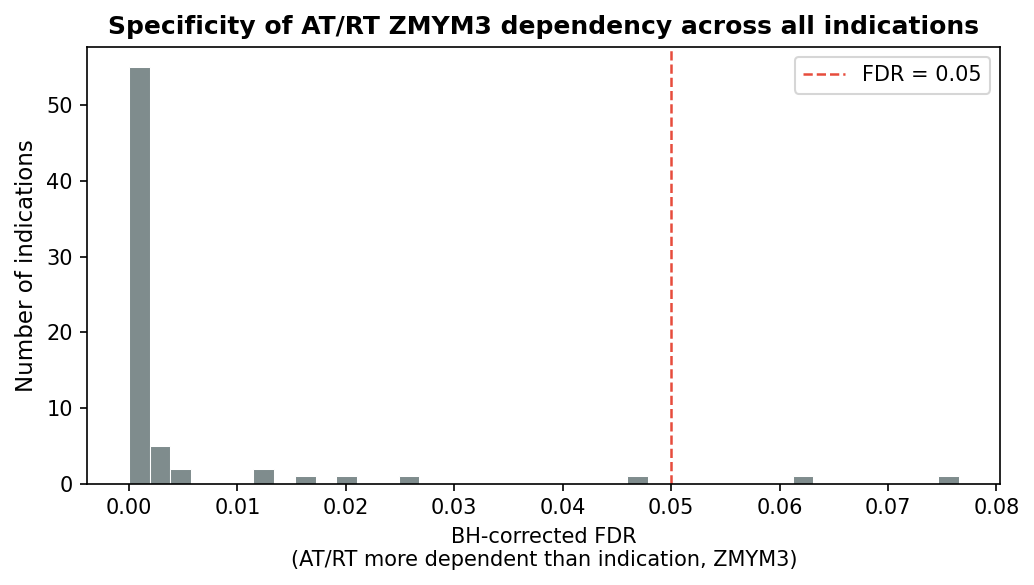

Saved: fig_extra_ZMYM3_specificity_fdr.pdf/png


In [ ]:
# ── Figure: FDR distribution across pairwise comparisons ──
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(spec_df['fdr'], bins=40, color='#7f8c8d',
        edgecolor='white', linewidth=0.5)
ax.axvline(FDR_THRESHOLD, color='#e74c3c', linestyle='--', linewidth=1.2,
           label=f'FDR = {FDR_THRESHOLD}')
ax.set_xlabel(f'BH-corrected FDR\n(AT/RT more dependent than indication, {TARGET_GENE})',
              fontsize=10)
ax.set_ylabel('Number of indications', fontsize=11)
ax.set_title(f'Specificity of AT/RT {TARGET_GENE} dependency across all indications',
             fontsize=12, fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f'fig_extra_{TARGET_GENE}_specificity_fdr.pdf'),
            bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, f'fig_extra_{TARGET_GENE}_specificity_fdr.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: fig_extra_{TARGET_GENE}_specificity_fdr.pdf/png')

## 2.6 Summary Table: All Consensus Genes by Indication

Export a comprehensive table of all context-specific fitness genes identified.

In [ ]:
# ── Build summary table ───────────────────────────────────
summary_rows = []

for indication, result in all_indication_results.items():
    df_all = result['all_results']
    for gene in result['consensus']:
        gene_row = df_all[df_all['gene'] == gene].iloc[0]
        summary_rows.append({
            'indication': indication,
            'gene': gene,
            'n_cell_lines': result['n_indication'],
            'mean_score_indication': gene_row['mean_in'],
            'mean_score_other': gene_row['mean_out'],
            'delta_mean': gene_row['mean_diff'],
            'dep_frac_indication': gene_row['dep_frac_in'],
            'dep_frac_other': gene_row['dep_frac_out'],
            'p_fisher': gene_row['p_fisher'],
            'p_ttest': gene_row['p_ttest'],
            'p_wilcoxon': gene_row.get('p_wilcoxon', np.nan),
            'consensus_type': '3-test' if result['use_wilcoxon'] else '2-test (N<10)',
        })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(['indication', 'p_fisher'])

print(f'Total consensus context-specific genes: {len(summary_df)}')
print(f'Across {summary_df["indication"].nunique()} indications\n')

# Save
summary_df.to_csv(os.path.join(DATA_DIR, '02_consensus_context_specific_genes.csv'), index=False)
print('Saved: 02_consensus_context_specific_genes.csv')

# Display
print(summary_df.to_string(index=False))

Total consensus context-specific genes: 130
Across 40 indications

Saved: 02_consensus_context_specific_genes.csv
                                             indication      gene  n_cell_lines  mean_score_indication  mean_score_other  delta_mean  dep_frac_indication  dep_frac_other     p_fisher       p_ttest   p_wilcoxon consensus_type
                                               AML, NOS      JAK2             4              -0.871071          0.129159   -1.000230             0.750000        0.002492 4.846305e-03  2.772561e-40 5.187793e-05  2-test (N<10)
                                               AML, NOS     RUNX1             4              -1.507186         -0.007570   -1.499616             1.000000        0.034053 1.000589e-02  1.103174e-22 2.484499e-04  2-test (N<10)
                                               AML, NOS     GATA1             4              -0.812029          0.009319   -0.821349             0.750000        0.004983 1.000589e-02  1.716588e-28 4.855371e-05  

In [ ]:
# ── Save all per-gene results for AT/RT ──────────────────
if ATRT_KEY:
    atrt_all = all_indication_results[ATRT_KEY]['all_results']
    atrt_all = atrt_all.sort_values('p_fisher')
    atrt_all.to_csv(os.path.join(DATA_DIR, '02_atrt_all_gene_results.csv'), index=False)
    print(f'Saved AT/RT full results: {len(atrt_all)} genes')
    print(f'\nTop 20 genes by Fisher p-value:')
    print(atrt_all.head(20)[['gene', 'mean_in', 'mean_out', 'mean_diff',
                             'p_fisher', 'p_ttest', 'p_wilcoxon']].to_string(index=False))

Saved AT/RT full results: 18420 genes

Top 20 genes by Fisher p-value:
    gene   mean_in  mean_out  mean_diff     p_fisher      p_ttest  p_wilcoxon
 SMARCD1 -0.816512 -0.207960  -0.608551 1.692250e-08 1.962180e-12    0.000037
   ZMYM3 -0.626475 -0.139272  -0.487203 2.255467e-06 1.371989e-13    0.000041
   NABP2 -0.634910 -0.150679  -0.484232 2.255467e-06 7.303024e-22    0.000145
    BRAP -0.622585 -0.231951  -0.390634 5.973238e-05 2.055625e-06    0.000698
   PPM1G -0.850792 -0.255407  -0.595384 4.089961e-04 3.830502e-15    0.000185
   PPM1D -0.756238 -0.244465  -0.511773 5.531633e-04 7.290233e-08    0.000447
    MIB1 -0.707599 -0.215859  -0.491741 2.790685e-03 5.735124e-07    0.000447
  FAM83E -0.480960 -0.230787  -0.250173 4.454349e-03 3.232090e-09    0.002874
    NXT1 -1.024100 -0.610047  -0.414053 4.454349e-03 5.051363e-02    0.006140
    PHIP -0.439688 -0.153394  -0.286294 5.428240e-03 2.312201e-06    0.021709
    MDM2 -1.159598 -0.639902  -0.519696 5.505531e-03 8.046631e-03    0.